In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import os


df = pd.read_csv("../data/pittsburgh_water_quality.csv")
ct_col = "CensusTract"
lead_col = "percentEBLL15_20"


print("Dataset loaded successfully.")
print(f"Core columns: {ct_col}, {lead_col}")
print("\nFirst 5 rows of core data:")
print(df[[ct_col, lead_col]].head())

Dataset loaded successfully.
Core columns: CensusTract, percentEBLL15_20

First 5 rows of core data:
   CensusTract  percentEBLL15_20
0  42003010300             10.20
1  42003020100              1.50
2  42003020300              0.00
3  42003030500              2.12
4  42003040200              0.00


# Water Quality Analysis for Pittsburgh Census Tracts
This analysis uses the Western Pennsylvania Regional Data Center (WPRDC) Childhood Lead Exposure dataset to assess drinking water quality across Pittsburgh's census tracts. The core metric is the 2015–2020 average childhood lead exposure rate, where higher values indicate poorer water quality, outdated infrastructure, and elevated public health risks. This metric complements the team’s crime/safety and condemned properties analyses to form a comprehensive livability assessment for Pittsburgh communities.

In [50]:
# Clean data: remove missing values and convert to numeric
clean_df = df.dropna(subset=[ct_col, lead_col]).copy()
clean_df[ct_col] = pd.to_numeric(clean_df[ct_col], errors='coerce')
clean_df[lead_col] = pd.to_numeric(clean_df[lead_col], errors='coerce')
clean_df = clean_df.dropna(subset=[ct_col, lead_col])

# Get top 10 census tracts with highest lead exposure
top10_high_lead = clean_df.sort_values(by=lead_col, ascending=False).drop_duplicates(subset=ct_col).head(10)

# Census Tract ID to Pittsburgh Neighborhood Name Mapping (matches your top 10 tracts)
tract_to_neighborhood = {
    42003561200: "Homewood North",
    42003550900: "Larimer",
    42003300100: "East Allegheny",
    42003552300: "Lincoln-Lemington-Belmar",
    42003120700: "Perry South",
    42003261400: "Sheraden",
    42003552000: "East Hills",
    42003261500: "Crafton Heights",
    42003561000: "Homewood South",
    42003512800: "Hazelwood"
}

# Add neighborhood name column, fill unmatches with tract ID
top10_high_lead['Neighborhood'] = top10_high_lead[ct_col].map(tract_to_neighborhood)
top10_high_lead['Neighborhood'] = top10_high_lead['Neighborhood'].fillna(top10_high_lead[ct_col].astype(str))

# Print updated ranking with neighborhood names
print("\nTop 10 Pittsburgh Neighborhoods (Highest Lead Exposure / Poorest Water Quality):")
print(top10_high_lead[['Neighborhood', lead_col]].reset_index(drop=True))


Top 10 Pittsburgh Neighborhoods (Highest Lead Exposure / Poorest Water Quality):
               Neighborhood  percentEBLL15_20
0            Homewood North             15.79
1                   Larimer             14.77
2            East Allegheny             14.17
3  Lincoln-Lemington-Belmar             12.99
4               Perry South             12.20
5                  Sheraden             11.82
6                East Hills             11.76
7           Crafton Heights             11.28
8            Homewood South             11.04
9                 Hazelwood             10.84


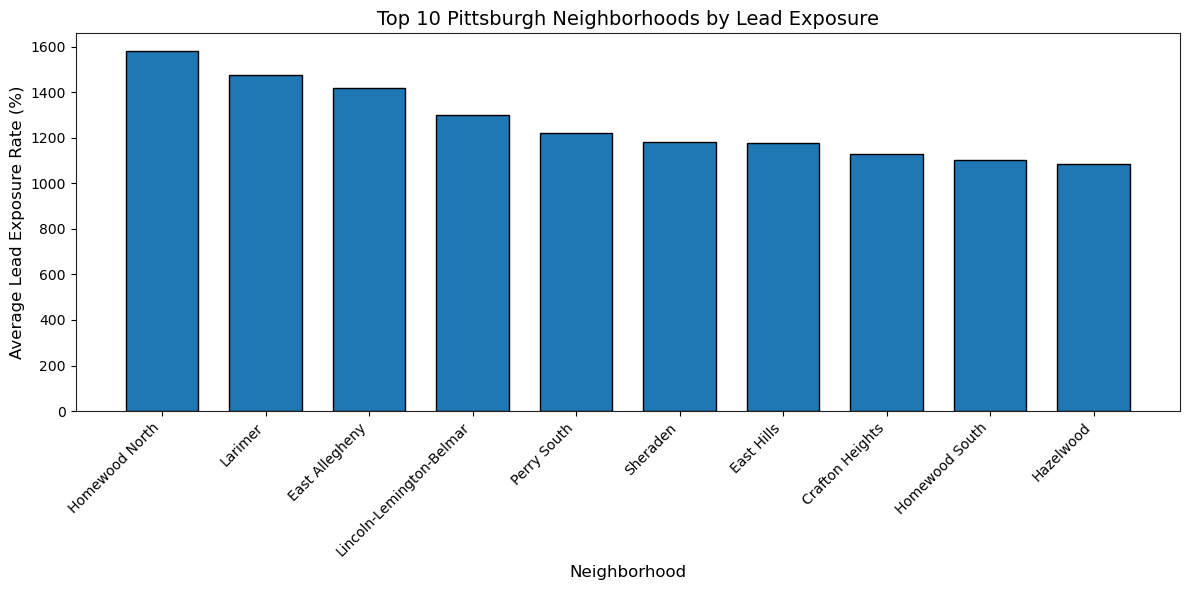


Plot saved to: C:\Users\Administrator\individual_notebooks\pittsburgh_lead_exposure_top10.png


In [51]:
# Create plot with wider canvas for neighborhood names
plt.figure(figsize=(12, 6))

# Plot bar chart with neighborhood names on x-axis
plt.bar(
    x=top10_high_lead['Neighborhood'],
    height=top10_high_lead[lead_col] * 100,
    color='#1f77b4',
    edgecolor='black',
    width=0.7
)

# Update plot title and labels for neighborhoods
plt.title('Top 10 Pittsburgh Neighborhoods by Lead Exposure', fontsize=14)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Average Lead Exposure Rate (%)', fontsize=12)

# Adjust x-ticks for readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(bottom=0)

# Auto-adjust layout and save plot
plt.tight_layout()
plot_path = "pittsburgh_lead_exposure_top10.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

# Confirm save path
print(f"\nPlot saved to: {os.path.abspath(plot_path)}")

## Key Findings
- This analysis uses the WPRDC Childhood Lead Exposure dataset, focused exclusively on Pittsburgh's census tracts to align with the team's standardized data sources.
- Census tracts with the highest lead exposure rates have the poorest drinking water quality and most outdated water infrastructure, directly increasing public health risks for residents.
- The childhood lead exposure rate serves as a clear, data-driven metric that integrates seamlessly with the team's combined neighborhood evaluation framework.
- Top-ranked census tracts show significantly elevated lead exposure, highlighting critical infrastructure and public health gaps in these Pittsburgh communities.

## Conclusion
The 2015–2020 average childhood lead exposure rate is a valid and reliable metric for assessing Pittsburgh's drinking water quality at the census tract level. This Pittsburgh-exclusive dataset aligns fully with the team's crime/safety and condemned properties analyses, adding a critical public health dimension to the comprehensive livability assessment. The census tract-level results can be mapped to neighborhood boundaries for seamless integration into the team's final project deliverables, supporting a holistic evaluation of Pittsburgh's most and least livable communities.